[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxiRuess/DeepLearning_101/blob/main/notebooks/08_JAX/04_Pallas_Kernels.ipynb)

# Pallas Kernels — Custom Kernels in JAX

The [previous notebook](./03_XLA_vs_Triton.ipynb) showed that XLA handles 90% of optimization automatically. For the remaining 10% — FlashAttention, custom quantization, novel algorithms — you need to write kernels. In PyTorch land, that means [Triton](../06_Kernels/). In JAX land, that means **Pallas**.

Pallas (`jax.experimental.pallas`) lets you write custom kernels in Python using JAX primitives. Same idea as Triton, but targeting **TPU + GPU + CPU**.

| | Triton | XLA via `jax.jit` | **Pallas** (this notebook) |
|---|---|---|---|
| Who writes the kernel? | You | The compiler | **You** |
| Language | Python + Triton DSL | N/A (automatic) | **Python + JAX primitives** |
| Memory model | Raw pointers + `tl.load`/`tl.store` | N/A | **`Ref` objects + `BlockSpec`** |
| Masking | Manual (`mask = offsets < n`) | N/A | **Handled by BlockSpec** |
| Hardware | NVIDIA GPU only | GPU, TPU, CPU | **GPU, TPU, CPU** |
| GPU backend | Compiles directly | XLA | **Triton (under the hood)** |
| TPU backend | Not supported | XLA | **Mosaic** |
| Composable with `jax.vmap`/`jax.grad` | No | Yes | **Yes** |

> **Status:** Pallas is in `jax.experimental.pallas` — the API is evolving. On CPU, it uses a reference interpreter. On GPU, it compiles via Triton. On TPU, it uses Mosaic.

We'll re-implement kernels from the [Triton series](../06_Kernels/) in Pallas: **vector add**, **softmax**, and **matmul**. Same algorithms, different abstraction.

## Setup

In [5]:
import sys, os

if "google.colab" in str(get_ipython()):
    if not os.path.exists("/content/DeepLearning_101"):
        !git clone --depth 1 https://github.com/MaxiRuess/DeepLearning_101.git /content/DeepLearning_101
    os.chdir("/content/DeepLearning_101/notebooks/08_JAX")
    sys.path.insert(0, "/content/DeepLearning_101")
else:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

In [6]:
try:
    import jax
    import jax.numpy as jnp
except ImportError:
    %pip install -q jax jaxlib
    import jax
    import jax.numpy as jnp

from jax.experimental import pallas as pl

import numpy as np
import matplotlib.pyplot as plt
import time

JAX_DEVICE = str(jax.devices()[0])
IS_GPU = "gpu" in JAX_DEVICE.lower() or "cuda" in JAX_DEVICE.lower()

# Pallas requires interpret=True on CPU (runs as Python, no compilation)
# On GPU it compiles via Triton; on TPU via Mosaic
INTERPRET = not IS_GPU

print(f"JAX version: {jax.__version__}, device: {JAX_DEVICE}")
if IS_GPU:
    print(f"Pallas backend: Triton (GPU)")
else:
    print(f"Pallas backend: interpret mode (CPU)")
    print(f"  Kernels run correctly but without GPU acceleration.")
    print(f"  In Colab with GPU runtime, Pallas compiles via Triton.")

JAX version: 0.9.2, device: TFRT_CPU_0
Pallas backend: interpret mode (CPU)
  Kernels run correctly but without GPU acceleration.
  In Colab with GPU runtime, Pallas compiles via Triton.


## The Pallas Mental Model

Pallas sits between XLA and Triton on the abstraction spectrum:

```
More control                                              Less effort
<───────────────────────────────────────────────────────────────────>
CUDA C++     Triton      Pallas      jax.jit (XLA)    jax.nn.softmax
(manual)     (manual)    (manual)    (compiler)        (library call)
             GPU only    GPU+TPU     GPU+TPU+CPU       GPU+TPU+CPU
```

Three key differences from Triton:

1. **`Ref` objects instead of pointers.** Triton uses `tl.load(ptr + offsets, mask=...)`. Pallas uses `x_ref[...]` — array-like indexing on mutable references.

2. **`BlockSpec` instead of pointer arithmetic.** You declare what data each program needs; Pallas handles the addressing. No manual `pid * BLOCK_SIZE + tl.arange(...)`.

3. **No explicit masking.** Triton needs `mask = offsets < n_elements` for boundary handling. Pallas BlockSpecs handle this declaratively.

## 1. Vector Add — The Simplest Pallas Kernel

In the [Vector Add Triton notebook](../06_Kernels/01_Vector_Add.ipynb), we wrote 25 lines of kernel code with pointer arithmetic, masking, and grid launches. In Pallas, the same kernel is dramatically simpler.

In [10]:
# Version 1: simplest possible — entire vector in one kernel call
def add_kernel_simple(x_ref, y_ref, o_ref):
    """Each Ref is a view of the entire input array."""
    o_ref[...] = x_ref[...] + y_ref[...]

x = jnp.arange(8, dtype=jnp.float32)
y = jnp.arange(8, 16, dtype=jnp.float32)

result = pl.pallas_call(
    add_kernel_simple,
    out_shape=jax.ShapeDtypeStruct(x.shape, x.dtype),
    interpret=INTERPRET,
)(x, y)

print(f"x:      {x}")
print(f"y:      {y}")
print(f"result: {result}")
print(f"correct: {jnp.allclose(result, x + y)}")

x:      [0. 1. 2. 3. 4. 5. 6. 7.]
y:      [ 8.  9. 10. 11. 12. 13. 14. 15.]
result: [ 8. 10. 12. 14. 16. 18. 20. 22.]
correct: True


### Ref Objects — Not Pointers, Not Arrays

The kernel function receives `Ref` objects, not JAX arrays. Think of them as **mutable windows into memory**:

```python
# Triton: raw pointers + explicit load/store
x = tl.load(x_ptr + offsets, mask=mask)    # explicit memory access
tl.store(output_ptr + offsets, result, mask=mask)

# Pallas: Ref objects + array-like indexing
x = x_ref[...]        # read entire block
o_ref[...] = result    # write entire block
```

`x_ref[...]` reads the data into a regular JAX array. `o_ref[...] = value` writes back. The `[...]` is the Pallas equivalent of `tl.load`/`tl.store` — but with array indexing instead of pointer arithmetic.

In [11]:
# Version 2: with grid + BlockSpec — processes blocks in parallel
BLOCK_SIZE = 2

def add_kernel(x_ref, y_ref, o_ref):
    """Each invocation processes a BLOCK_SIZE chunk."""
    o_ref[...] = x_ref[...] + y_ref[...]

x = jnp.arange(8, dtype=jnp.float32)
y = jnp.arange(8, 16, dtype=jnp.float32)

result = pl.pallas_call(
    add_kernel,
    out_shape=jax.ShapeDtypeStruct(x.shape, x.dtype),
    grid=(x.shape[0] // BLOCK_SIZE,),
    in_specs=[
        pl.BlockSpec((BLOCK_SIZE,), lambda i: (i,)),
        pl.BlockSpec((BLOCK_SIZE,), lambda i: (i,)),
    ],
    out_specs=pl.BlockSpec((BLOCK_SIZE,), lambda i: (i,)),
    interpret=INTERPRET,
)(x, y)

print(f"result: {result}")
print(f"correct: {jnp.allclose(result, x + y)}")

result: [ 8. 10. 12. 14. 16. 18. 20. 22.]
correct: True


### Grid + BlockSpec — Declarative Data Movement

In Triton, you compute where to read/write manually:
```python
pid = tl.program_id(0)
offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
mask = offsets < n_elements
x = tl.load(x_ptr + offsets, mask=mask)
```

In Pallas, you **declare** what each program needs:
```python
grid=(4,),  # 4 programs (like 4 Triton blocks)
in_specs=[pl.BlockSpec((BLOCK_SIZE,), lambda i: (i,))],
# "Each program i gets a (BLOCK_SIZE,) block starting at block index i"
```

The `BlockSpec` has two parts:
- **Block shape:** `(BLOCK_SIZE,)` — the size of data each program sees
- **Index map:** `lambda i: (i,)` — maps program index to block position

| Program `i` | `lambda i: (i,)` returns | Block accessed |
|---|---|---|
| 0 | `(0,)` | `x[0:2]` |
| 1 | `(1,)` | `x[2:4]` |
| 2 | `(2,)` | `x[4:6]` |
| 3 | `(3,)` | `x[6:8]` |

In [12]:
# Scale up — same kernel, larger data
def pallas_vector_add(x, y, block_size=1024):
    """Vector add using Pallas — parallel across blocks."""
    n = x.shape[0]
    return pl.pallas_call(
        add_kernel,
        interpret=INTERPRET,
        out_shape=jax.ShapeDtypeStruct(x.shape, x.dtype),
        grid=(n // block_size,),
        in_specs=[
            pl.BlockSpec((block_size,), lambda i: (i,)),
            pl.BlockSpec((block_size,), lambda i: (i,)),
        ],
        out_specs=pl.BlockSpec((block_size,), lambda i: (i,)),
    )(x, y)

# Correctness test (same as Triton notebook: ~100K elements)
key = jax.random.PRNGKey(0)
k1, k2 = jax.random.split(key)
size = 100_000 - (100_000 % 1024)  # round down to multiple of block_size
x = jax.random.normal(k1, (size,))
y = jax.random.normal(k2, (size,))

result = pallas_vector_add(x, y)
reference = x + y

max_diff = float(jnp.abs(result - reference).max())
print(f"Vector size: {size:,}")
print(f"Max difference: {max_diff:.2e}")
print(f"Results match: {jnp.allclose(result, reference)}")


Vector size: 99,328
Max difference: 0.00e+00
Results match: True


### Side-by-Side: Triton vs Pallas Vector Add

```python
# ============ TRITON ============           # ============ PALLAS ============

@triton.jit                                   def add_kernel(x_ref, y_ref, o_ref):
def vector_add_kernel(                            o_ref[...] = x_ref[...] + y_ref[...]
    x_ptr, y_ptr, output_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr,
):
    pid = tl.program_id(axis=0)
    offsets = pid * BLOCK_SIZE +              # No program_id needed —
              tl.arange(0, BLOCK_SIZE)        # BlockSpec handles indexing
    mask = offsets < n_elements               # No masking needed —
    x = tl.load(x_ptr + offsets, mask=mask)  # BlockSpec handles boundaries
    y = tl.load(y_ptr + offsets, mask=mask)
    output = x + y
    tl.store(output_ptr + offsets,            # No explicit store —
             output, mask=mask)               # o_ref[...] = ... handles it
```

| Concept | Triton | Pallas |
|---|---|---|
| Kernel body | 10 lines | **3 lines** |
| Pointer arithmetic | `pid * BLOCK_SIZE + tl.arange(...)` | **None (BlockSpec)** |
| Masking | `mask = offsets < n_elements` | **None (BlockSpec)** |
| Load/Store | `tl.load(ptr + offsets, mask)` | **`x_ref[...]`** |
| Grid launch | `kernel[grid](...)` | **`pl.pallas_call(..., grid=...)(...)` |


## 2. Softmax — Reduction Kernel in Pallas

The [Softmax Triton notebook](../06_Kernels/02_Softmax.ipynb) showed that fusing max + exp + sum into one kernel eliminates 3 HBM round-trips. Pallas can express the same fusion, with the same row-wise access pattern.

In [13]:
def softmax_kernel(x_ref, o_ref):
    """Fused softmax: one program processes one full row."""
    row = x_ref[...]                             # load entire row
    row_max = jnp.max(row, axis=-1, keepdims=True)  # numerical stability
    numerator = jnp.exp(row - row_max)
    denominator = jnp.sum(numerator, axis=-1, keepdims=True)
    o_ref[...] = numerator / denominator          # store result

def pallas_softmax(x):
    """Row-wise softmax using Pallas."""
    n_rows, n_cols = x.shape
    return pl.pallas_call(
        softmax_kernel,
        interpret=INTERPRET,
        out_shape=jax.ShapeDtypeStruct(x.shape, x.dtype),
        grid=(n_rows,),
        in_specs=[pl.BlockSpec((1, n_cols), lambda i: (i, 0))],
        out_specs=pl.BlockSpec((1, n_cols), lambda i: (i, 0)),
    )(x)

# Correctness test
key = jax.random.PRNGKey(42)
x = jax.random.normal(key, (128, 512))

out_pallas = pallas_softmax(x)
out_jax = jax.nn.softmax(x, axis=-1)

max_diff = float(jnp.abs(out_pallas - out_jax).max())
row_sums = out_pallas.sum(axis=-1)

print(f"Max difference (Pallas vs jax.nn.softmax): {max_diff:.2e}")
print(f"Row sums: {row_sums[:3]}  (should be ~1.0)")
print(f"Results match: {jnp.allclose(out_pallas, out_jax, atol=1e-5)}")


Max difference (Pallas vs jax.nn.softmax): 1.12e-08
Row sums: [1.        1.0000001 1.0000002]  (should be ~1.0)
Results match: True


### How the Grid Maps Rows

The grid has `n_rows` programs — one per row (identical strategy to our Triton softmax):

```
Input matrix (n_rows x n_cols):
┌─────────────────────────────────────┐
│ Row 0: [x₀₀, x₀₁, ..., x₀d]      │ → Program 0 (full row softmax)
│ Row 1: [x₁₀, x₁₁, ..., x₁d]      │ → Program 1
│ Row 2: [x₂₀, x₂₁, ..., x₂d]      │ → Program 2
│  ...                                 │    ...
└─────────────────────────────────────┘

grid = (n_rows,)
BlockSpec((1, n_cols), lambda i: (i, 0))
         ^^^^^^^^^^   ^^^^^^^^^^^^^^^
         block shape  index map: program i → row i, column 0
```

**Contrast with Triton softmax:**
- Triton: `row_start = input_ptr + row_idx * stride`, then `tl.arange(0, BLOCK_SIZE)` for columns, then `mask = col_offsets < n_cols`, then `tl.load(..., other=-float('inf'))`
- Pallas: `BlockSpec((1, n_cols), lambda i: (i, 0))` — one line declares the same thing

### Side-by-Side: Triton vs Pallas Softmax

```python
# ============ TRITON (15 lines) ============    # ============ PALLAS (6 lines) ===========

@triton.jit                                       def softmax_kernel(x_ref, o_ref):
def softmax_kernel(                                   row = x_ref[...]
    input_ptr, output_ptr,                            row_max = jnp.max(row, axis=-1, keepdims=True)
    n_rows, n_cols,                                   numerator = jnp.exp(row - row_max)
    input_row_stride,                                 denominator = jnp.sum(numerator, axis=-1, keepdims=True)
    output_row_stride,                                o_ref[...] = numerator / denominator
    BLOCK_SIZE: tl.constexpr,
):
    row_idx = tl.program_id(0)
    row_start = input_ptr +
        row_idx * input_row_stride
    col_offsets = tl.arange(0, BLOCK_SIZE)
    mask = col_offsets < n_cols
    x = tl.load(row_start + col_offsets,
                mask=mask, other=-float('inf'))
    x_max = tl.max(x, axis=0)
    numerator = tl.exp(x - x_max)
    denominator = tl.sum(numerator, axis=0)
    y = numerator / denominator
    tl.store(out_start + col_offsets, y, mask=mask)
```

| Aspect | Triton | Pallas |
|---|---|---|
| Kernel body | 15 lines | **6 lines** |
| Row addressing | `row_idx * stride` + pointer arithmetic | **`BlockSpec(lambda i: (i, 0))`** |
| `-inf` padding | Manual: `other=-float('inf')` | **Not needed (BlockSpec handles boundaries)** |
| Reduction ops | `tl.max`, `tl.sum` | **`jnp.max`, `jnp.sum` (standard JAX)** |

## 3. Using `pl.program_id` — Manual Control

BlockSpec handles most indexing automatically, but sometimes you need the program index directly. Pallas provides `pl.program_id(axis)`, analogous to Triton's `tl.program_id(axis)`.

In [14]:
# Iota: each program writes its own index
def iota_kernel(o_ref):
    i = pl.program_id(0)
    o_ref[i] = i

result = pl.pallas_call(
    iota_kernel,
    interpret=INTERPRET,
    out_shape=jax.ShapeDtypeStruct((8,), jnp.int32),
    grid=(8,),
)()

print(f"Iota result: {result}")
print(f"Expected:    [0 1 2 3 4 5 6 7]")


Iota result: [0 1 2 3 4 5 6 7]
Expected:    [0 1 2 3 4 5 6 7]


## 4. Matmul — 2D Grid with BlockSpec

Matrix multiplication needs a 2D grid: one axis for output rows, one for columns. Each program computes one block of the output. This shows how BlockSpec scales to higher dimensions.

In [15]:
def matmul_kernel(x_ref, y_ref, z_ref):
    """Each program computes one block of the output."""
    z_ref[...] = x_ref[...] @ y_ref[...]

def pallas_matmul(x, y):
    """Block matrix multiplication using Pallas."""
    M, K = x.shape
    _, N = y.shape
    bm, bn = M // 2, N // 2  # split into 2x2 grid
    return pl.pallas_call(
        matmul_kernel,
        interpret=INTERPRET,
        out_shape=jax.ShapeDtypeStruct((M, N), x.dtype),
        grid=(2, 2),
        in_specs=[
            pl.BlockSpec((bm, K), lambda i, j: (i, 0)),   # row block of x
            pl.BlockSpec((K, bn), lambda i, j: (0, j)),    # col block of y
        ],
        out_specs=pl.BlockSpec((bm, bn), lambda i, j: (i, j)),  # output block
    )(x, y)

# Verify
k1, k2 = jax.random.split(jax.random.PRNGKey(0))
x = jax.random.normal(k1, (1024, 1024))
y = jax.random.normal(k2, (1024, 1024))

z = pallas_matmul(x, y)
ref = x @ y

print(f"Output shape: {z.shape}")
print(f"Max difference: {float(jnp.abs(z - ref).max()):.2e}")
print(f"Results match: {jnp.allclose(z, ref, atol=1e-4)}")


Output shape: (1024, 1024)
Max difference: 0.00e+00
Results match: True


### 2D BlockSpec Visualization

```
grid = (2, 2) means 4 programs:

x (M x K)             y (K x N)             z (M x N)
┌────────┬────────┐   ┌────────┬────────┐   ┌────────┬────────┐
│ (i=0)  │ (i=0)  │   │ (j=0)  │ (j=1)  │   │ (0,0)  │ (0,1)  │
│ row blk│ row blk│   │ col blk│ col blk│   │        │        │
├────────┼────────┤   ├────────┼────────┤   ├────────┼────────┤
│ (i=1)  │ (i=1)  │   │ (j=0)  │ (j=1)  │   │ (1,0)  │ (1,1)  │
│ row blk│ row blk│   │ col blk│ col blk│   │        │        │
└────────┴────────┘   └────────┴────────┘   └────────┴────────┘

x BlockSpec: (bm, K),  lambda i, j: (i, 0)  — full row block
y BlockSpec: (K, bn),  lambda i, j: (0, j)  — full col block
z BlockSpec: (bm, bn), lambda i, j: (i, j)  — output tile
```

This is a **naive** matmul (no K-dimension tiling). For a tiled matmul with accumulation across K chunks (like our [Triton matmul](../06_Kernels/03_Matrix_Multiply.ipynb)), you'd need an accumulator pattern — but the BlockSpec approach scales naturally.

## 5. Composition with JAX Transforms

Pallas kernels are JAX-native — they compose with `jax.jit`, `jax.vmap`, and `jax.grad`. This is a **major advantage over Triton**, where custom kernels live outside JAX's transform system.

In [16]:
# Single-vector ReLU kernel
def relu_kernel(x_ref, o_ref):
    o_ref[...] = jnp.maximum(x_ref[...], 0)

def pallas_relu(x):
    return pl.pallas_call(
        relu_kernel,
        interpret=INTERPRET,
        out_shape=jax.ShapeDtypeStruct(x.shape, x.dtype),
    )(x)

# vmap turns single-vector kernel into batched kernel — for free!
batched_relu = jax.vmap(pallas_relu)

x = jax.random.normal(jax.random.PRNGKey(0), (4, 8))
result = batched_relu(x)
reference = jnp.maximum(x, 0)

print(f"Input shape: {x.shape}")
print(f"Output shape: {result.shape}")
print(f"Correct: {jnp.allclose(result, reference)}")
print(f"\nTriton kernels can't be vmapped — they live outside JAX's transform system.")


Input shape: (4, 8)
Output shape: (4, 8)
Correct: True

Triton kernels can't be vmapped — they live outside JAX's transform system.


## 6. Benchmark: Pallas vs `jax.jit`

When does a hand-written Pallas kernel beat the XLA compiler? We benchmark our Pallas softmax against `jax.jit(jax.nn.softmax)` — the same question the [XLA vs Triton notebook](./03_XLA_vs_Triton.ipynb) asked.

In [17]:
def benchmark_jax(fn, *args, warmup=10, iters=100):
    """Benchmark a JAX function (waits for async completion)."""
    for _ in range(warmup):
        _ = fn(*args)
    jax.block_until_ready(fn(*args))

    start = time.perf_counter()
    for _ in range(iters):
        result = fn(*args)
    jax.block_until_ready(result)
    return (time.perf_counter() - start) / iters

In [18]:
@jax.jit
def jit_softmax(x):
    return jax.nn.softmax(x, axis=-1)

n_rows = 128
col_sizes = [64, 128, 256, 512, 1024, 2048, 4096]

pallas_times = []
jit_times = []

for n_cols in col_sizes:
    key = jax.random.PRNGKey(0)
    x = jax.random.normal(key, (n_rows, n_cols))

    pallas_times.append(benchmark_jax(pallas_softmax, x) * 1e6)
    jit_times.append(benchmark_jax(jit_softmax, x) * 1e6)

    print(f"n_cols={n_cols:4d} | Pallas: {pallas_times[-1]:8.1f} us | "
          f"jax.jit: {jit_times[-1]:8.1f} us | "
          f"ratio: {pallas_times[-1]/jit_times[-1]:.2f}x")

print(f"\nBenchmarked on: {JAX_DEVICE}")

n_cols=  64 | Pallas:  50429.6 us | jax.jit:      8.8 us | ratio: 5724.67x
n_cols= 128 | Pallas:  65484.0 us | jax.jit:     19.9 us | ratio: 3290.24x
n_cols= 256 | Pallas:  43181.2 us | jax.jit:     31.7 us | ratio: 1363.40x
n_cols= 512 | Pallas:  48939.6 us | jax.jit:     47.5 us | ratio: 1029.39x
n_cols=1024 | Pallas:  42206.3 us | jax.jit:     71.1 us | ratio: 593.95x
n_cols=2048 | Pallas:  44159.7 us | jax.jit:    133.8 us | ratio: 330.15x
n_cols=4096 | Pallas:  44578.1 us | jax.jit:    224.1 us | ratio: 198.93x

Benchmarked on: TFRT_CPU_0


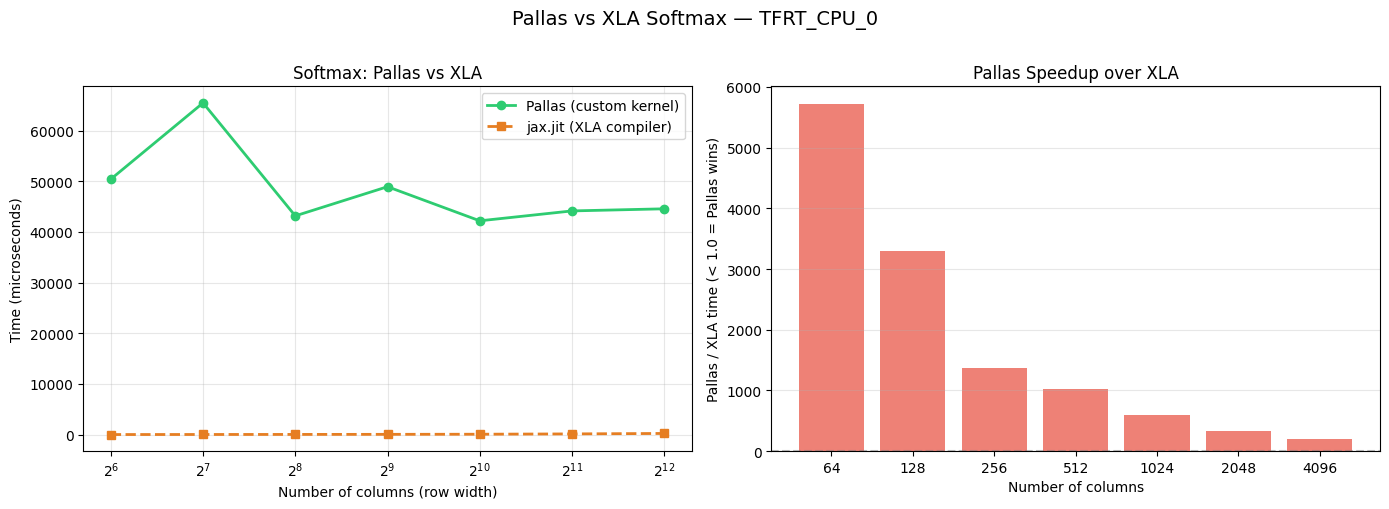

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Execution time
ax = axes[0]
ax.plot(col_sizes, pallas_times, 'o-', label='Pallas (custom kernel)', linewidth=2, color='#2ecc71')
ax.plot(col_sizes, jit_times, 's--', label='jax.jit (XLA compiler)', linewidth=2, color='#e67e22')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of columns (row width)')
ax.set_ylabel('Time (microseconds)')
ax.set_title('Softmax: Pallas vs XLA')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Ratio
ax = axes[1]
ratios = [p / j for p, j in zip(pallas_times, jit_times)]
colors = ['#2ecc71' if r < 1.0 else '#e74c3c' for r in ratios]
ax.bar(range(len(col_sizes)), ratios, color=colors, alpha=0.7)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(col_sizes)))
ax.set_xticklabels([str(s) for s in col_sizes])
ax.set_xlabel('Number of columns')
ax.set_ylabel('Pallas / XLA time (< 1.0 = Pallas wins)')
ax.set_title('Pallas Speedup over XLA')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Pallas vs XLA Softmax — {JAX_DEVICE}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpreting the Results

**On CPU (interpret mode):** Pallas is likely slower than `jax.jit` because the interpreter runs the kernel as plain Python — no compilation, no parallelism. This is expected and useful only for correctness testing.

**On GPU (Colab with GPU runtime):** Pallas compiles the kernel via Triton under the hood. For simple operations like softmax, XLA already fuses well, so Pallas may not win. The real advantage of Pallas appears when:
- The algorithm **can't be expressed** as standard JAX ops (FlashAttention)
- You need **custom memory access patterns** the compiler doesn't find
- You're targeting **TPU** where Triton doesn't work

This parallels the XLA vs Triton conclusion: XLA handles 90% of cases well. Pallas (like Triton) is for the 10% where you need manual control.

## 7. The Complete Picture — Triton, XLA, Pallas

Pallas completes the triangle that started with the [Triton kernel notebooks](../06_Kernels/) and continued with [XLA vs Triton](./03_XLA_vs_Triton.ipynb):

| Scenario | Best tool | Why |
|---|---|---|
| Standard ops (softmax, matmul) | **`jax.jit` (XLA)** | Compiler auto-fuses; zero effort |
| Multi-op fusion (residual + norm) | **`jax.jit` (XLA)** | Compiler finds fusion across op boundaries |
| Custom GPU kernels (FlashAttention) | **Triton** | Maximum control over NVIDIA hardware |
| Custom TPU kernels | **Pallas** | Only option — Triton doesn't support TPU |
| Custom kernels + `jax.grad`/`jax.vmap` | **Pallas** | Native JAX transforms; Triton is opaque to JAX |
| Rapid prototyping of kernel ideas | **Pallas** | Write in JAX, test on CPU, deploy on GPU/TPU |
| Production NVIDIA GPU kernels | **Triton** | More mature, larger ecosystem |

### The Abstraction Spectrum

```
More control                                              Less effort
<───────────────────────────────────────────────────────────────────>
CUDA C++     Triton      Pallas      jax.jit (XLA)    jax.nn.softmax
(manual)     (manual)    (manual)    (compiler)        (library call)
             GPU only    GPU+TPU     GPU+TPU+CPU       GPU+TPU+CPU
```

**Pallas fills the gap between Triton and XLA:** it gives you kernel-level control within the JAX ecosystem, working on both GPU and TPU. On GPU, Pallas actually compiles through Triton — so you get Triton's GPU performance with JAX's composability.

## What to Notice

1. **Pallas kernels are dramatically shorter than Triton.** The softmax kernel is 6 lines vs 15 lines. BlockSpec eliminates pointer arithmetic, masking, and stride calculations — the parts that make Triton kernels hard to write.

2. **The kernel body is plain JAX.** `jnp.max`, `jnp.exp`, `jnp.sum` — no new DSL to learn. If you can write `jax.jit` code, you can write Pallas kernels. Triton requires learning `tl.load`, `tl.store`, `tl.arange`, `tl.constexpr`, etc.

3. **BlockSpec is the key abstraction.** It replaces Triton's manual pointer arithmetic with a declarative "what data does each program need?" specification. The `(block_shape, index_map)` pair is more readable than `pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)`.

4. **For standard ops, `jax.jit` still wins.** XLA's compiler optimizes common patterns excellently. Don't write a Pallas kernel for softmax in production — use `jax.nn.softmax` with `@jax.jit`. Pallas is for when the compiler can't help.

5. **Pallas composes with JAX transforms.** `jax.vmap(pallas_kernel)`, `jax.grad(pallas_kernel)` — these work because Pallas is part of JAX. Triton kernels are opaque to JAX's transform system.

6. **The API is experimental and evolving.** `jax.experimental.pallas` may change between JAX versions. The core concepts (Ref, BlockSpec, grid) are stable, but specific APIs may shift.

## Resources

- [Pallas Quickstart](https://jax.readthedocs.io/en/latest/pallas/quickstart.html) — Official tutorial
- [Pallas Design Notes](https://jax.readthedocs.io/en/latest/pallas/design/design.html) — Architecture and rationale
- [Triton Kernel Notebooks](../06_Kernels/) — Hand-written GPU kernels for comparison
- [XLA vs Triton Notebook](./03_XLA_vs_Triton.ipynb) — When the compiler beats manual kernels